# README
This notebook implements and trains a deep learning model for 3D thyroid nodule reconstruction from two approximately orthogonal freehand ultrasound sweeps, and fine-tunes it on clinical data from Hospital Universitario Ramón y Cajal.

Developed by Silvia Martin Suazo and Sofiya Sokolovskaya as part of Sofiya's Bachelor's Final Project at U-TAD, Madrid.

Before running it, make sure that the notebook is ready to run on GPU and that the root directory contains two files:
- `Data.zip` -- the preprocessed Decathlon dataset for the baseline model learning
- `hospital_flat.zip` -- the reorganised Thyroid nodules dataset from Ramón y Cajal hospital for fine-tuning

Running the whole notebook on Google Colab with T4 takes approximately 5 hours, mostly due to the length of the baseline model training.

To run only the fine-tuning part:
1. Create a `./checkpoints_volumetric/` folder.
2. Upload the `best_model.pt` to `./checkpoints_volumetric/`.
3. Run all cells in order, skipping the ones in the "Main execution" section.

In [ ]:
!apt-get update
!apt-get install -y unzip
!unzip Data.zip
!unzip hospital_flat.zip

Streaming output truncated to the last 5000 lines.
  inflating: hospital_flat/ULT153_nod1_trans_p1/101.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/102.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/103.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/104.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/105.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/106.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/107.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/108.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/109.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/11.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/110.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/111.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/112.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/113.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/114.png  
  inflating: hospital_flat/ULT153_nod1_trans_p1/115.png  
  inflating: hospital_

In [ ]:
## MAKING SURE ENVIRONMENT HAS ALL LIBRARIES THIS IS FOR RUNPOD
import os

!apt-get update -qq
!apt-get install -y -qq libjpeg-dev libopenjp2-7-dev

!pip install -q optuna SimpleITK numpy torch torchvision matplotlib scipy
!pip install -q pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.9 MB/s eta 0:00:00


In [ ]:
# 1. Now we import everything
import torch
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import Tuple, List, Optional, Dict, Any
import torch.nn as nn
import torch.nn.functional as TorchF
import torch.optim as optim
from torch.utils.checkpoint import checkpoint
import optuna
import numpy as np
import SimpleITK as sitk
from PIL import Image
import collections
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.ndimage import distance_transform_edt
import sys
import re

# 1. Load Data

In [ ]:
class ResizeAndPad:
    """
    Resizes each image so that the widest dimension has the desired size,
    and pads it to make it square.
    """
    def __init__(self, output_size: int, fill: int = 0):
        self.output_size = output_size
        self.fill = fill

    def __call__(self, img: Image.Image) -> Image.Image:
        original_width, original_height = img.size
        aspect_ratio = original_width / original_height

        if original_width > original_height:
            new_width = self.output_size
            new_height = int(new_width / aspect_ratio)
        else:
            new_height = self.output_size
            new_width = int(new_height * aspect_ratio)

        img = transforms.functional.resize(img, (new_height, new_width))

        pad_left = (self.output_size - new_width) // 2
        pad_top = (self.output_size - new_height) // 2
        pad_right = self.output_size - new_width - pad_left
        pad_bottom = self.output_size - new_height - pad_top

        return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom), self.fill)


class PairedSegmentedVideoDataset(Dataset):
    """
    Dataset for paired ultrasound views.
    """
    def __init__(
        self,
        file_pairs: List[Dict],
        transform: transforms.Compose,
        num_frames: int = 64
    ):
        self.file_pairs = file_pairs
        self.transform = transform
        self.num_frames = num_frames

    def __len__(self) -> int:
        return len(self.file_pairs)

    def _load_video(self, folder: str) -> torch.Tensor:
        """Load all PNG frames from a segmentation folder."""
        frames = []

        # Get all PNG files with numeric names
        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(".png") and os.path.splitext(f)[0].isdigit()
        ]
        files = sorted(files, key=lambda x: int(os.path.splitext(x)[0]))

        if not files:
            raise ValueError(f"No valid .png frames found in {folder}")

        for fname in files:
            img_path = os.path.join(folder, fname)
            # Load as binary (1-bit) image
            img = Image.open(img_path).convert("1")
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        return torch.stack(frames)

    def _resample_frames(self, video: torch.Tensor) -> torch.Tensor:
        """
        Resamples video to self.num_frames frames via nearest neighbor interpolation.
        """
        F, C, H, W = video.shape

        if F == self.num_frames:
            return video

        # Use nearest neighbor for binary masks
        video = video.permute(1, 0, 2, 3).unsqueeze(0)  # (1, C, F, H, W)
        video = torch.nn.functional.interpolate(
            video,
            size=(self.num_frames, H, W),
            mode='nearest'
        )
        video = video.squeeze(0).permute(1, 0, 2, 3)  # (F, C, H, W)
        return video

    def __getitem__(self, idx):
        pair_info = self.file_pairs[idx]

        trans_video = self._load_video(pair_info['transversal'])
        long_video  = self._load_video(pair_info['longitudinal'])

        trans_video = self._resample_frames(trans_video)
        long_video  = self._resample_frames(long_video)

        # Load 3D segmentation volume
        sitk_img = sitk.ReadImage(pair_info['volume_3d'])
        vol = sitk.GetArrayFromImage(sitk_img).astype(np.float32)  # (D, H, W)
        vol = torch.from_numpy(vol).unsqueeze(0)  # (1, D, H, W)
        vol = TorchF.interpolate(
            vol.unsqueeze(0), size=(128, 128, 128), mode='trilinear', align_corners=False
        ).squeeze(0)  # (1, 128, 128, 128)

        metadata = {
            'patient_id': pair_info['patient_id'],
            'nodule_info': pair_info['nodule_info'],
        }

        return trans_video, long_video, vol, metadata

def find_and_pair_segmentations(
    dataset_path: str,
    val_frac: float = 0.1,
    test_frac: float = 0.1,
    seed: int = 42
) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """
    Returns paired transversal/longitudinal folders along with the corresponding 3D volume path for each split.
    """
    random.seed(seed)
    patient_nodules = collections.defaultdict(
        lambda: collections.defaultdict(lambda: {"transversal": [], "longitudinal": []})
    )

    # Step 1: collect segmentation folders
    for patient_dir in os.listdir(dataset_path):
        patient_path = os.path.join(dataset_path, patient_dir)
        if not os.path.isdir(patient_path):
            continue

        patient_id = patient_dir

        for video_dir in os.listdir(patient_path):
            video_path = os.path.join(patient_path, video_dir)
            if not os.path.isdir(video_path):
                continue

            if "Transversal" in video_dir or "transversal" in video_dir.lower():
                view_type = "transversal"
            elif "Longitudinal" in video_dir or "longitudinal" in video_dir.lower():
                view_type = "longitudinal"
            else:
                continue

            seg_root = os.path.join(video_path, "segmentation")
            if not os.path.isdir(seg_root):
                continue

            for nodule_folder in os.listdir(seg_root):
                nodule_path = os.path.join(seg_root, nodule_folder)
                if not os.path.isdir(nodule_path):
                    continue

                # Extract nodule/pass info
                parts = nodule_folder.split('_')
                nodule_id, pass_id = None, None
                for i, part in enumerate(parts):
                    if part == 'nod' and i + 1 < len(parts):
                        nodule_id = parts[i + 1]
                    if part == 'pasada' and i + 1 < len(parts):
                        pass_id = parts[i + 1]
                if nodule_id is None:
                    nodule_id = nodule_folder
                nodule_key = f"nod_{nodule_id}_pass_{pass_id}" if pass_id else f"nod_{nodule_id}"

                patient_nodules[patient_id][nodule_key][view_type].append(nodule_path)

    # Step 2: create all valid pairs
    all_pairs = []
    for patient_id, nodules in patient_nodules.items():
        for nodule_key, views in nodules.items():
            trans = views["transversal"]
            longi = views["longitudinal"]
            if not trans or not longi:
                continue

            for t_path in trans:
                for l_path in longi:
                    all_pairs.append({
                        "patient_id": patient_id,
                        "nodule_info": nodule_key,
                        "transversal": t_path,
                        "longitudinal": l_path,
                        "volume_3d": os.path.join(
                            dataset_path, patient_id,
                            "volume_3d", nodule_key, "segmentation.nii.gz"
                        )
                    })

    if not all_pairs:
        raise ValueError("No valid transversal-longitudinal pairs found.")

    # Step 3: split by patient
    all_patients = sorted(list(patient_nodules.keys()))
    random.shuffle(all_patients)

    n_test = max(1, int(len(all_patients) * test_frac))
    n_val = max(1, int(len(all_patients) * val_frac))

    test_patients = set(all_patients[:n_test])
    val_patients = set(all_patients[n_test:n_test + n_val])
    train_patients = set(all_patients[n_test + n_val:])

    train_pairs = [p for p in all_pairs if p['patient_id'] in train_patients]
    val_pairs   = [p for p in all_pairs if p['patient_id'] in val_patients]
    test_pairs  = [p for p in all_pairs if p['patient_id'] in test_patients]

    # Step 4: keep both views as inputs (no source/target split)
    def make_pairs(pairs):
        new_pairs = []
        for p in pairs:
            new_pairs.append({
                "transversal": p["transversal"],
                "longitudinal": p["longitudinal"],
                "patient_id": p["patient_id"],
                "nodule_info": p["nodule_info"],
                "volume_3d": p["volume_3d"],   # <-- add this line
            })
        return new_pairs

    train_pairs = make_pairs(train_pairs)
    val_pairs   = make_pairs(val_pairs)
    test_pairs  = make_pairs(test_pairs)

    return train_pairs, val_pairs, test_pairs

def get_segmented_video_loader(
    train_pairs: List[Dict],
    val_pairs: List[Dict],
    test_pairs: List[Dict],
    batch_size: int = 4,
    final_img_size: int = 128,
    num_frames: int = 64,
    bidirectional: bool = False  # Keep for compatibility but it's ignored
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Creates DataLoaders for training, validation, and testing.
    """
    transform = transforms.Compose([
        ResizeAndPad(output_size=final_img_size),
        transforms.ToTensor(),
    ])

    train_dataset = PairedSegmentedVideoDataset(train_pairs, transform=transform, num_frames=num_frames)
    val_dataset = PairedSegmentedVideoDataset(val_pairs, transform=transform, num_frames=num_frames)
    test_dataset = PairedSegmentedVideoDataset(test_pairs, transform=transform, num_frames=num_frames)

    def collate_fn(batch):
        source_videos  = torch.stack([item[0] for item in batch])
        target_videos  = torch.stack([item[1] for item in batch])
        target_volumes = torch.stack([item[2] for item in batch])
        metadata       = [item[3] for item in batch]
        return source_videos, target_videos, target_volumes, metadata

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

# 2. Models

## ResNet

In [ ]:
class Block(nn.Module):
    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, i_downsample: Optional[nn.Module] = None, stride: int = 1):
        super(Block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False)
        self.batch_norm2 = nn.BatchNorm2d(out_channels)
        self.i_downsample = i_downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x); out = self.batch_norm1(out); out = self.relu(out)
        out = self.conv2(out); out = self.batch_norm2(out)
        if self.i_downsample is not None:
            identity = self.i_downsample(x)
        out += identity
        out = self.relu(out)
        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels: int, out_channels: int, i_downsample: Optional[nn.Module] = None, stride: int = 1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.batch_norm2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, padding=0, bias=False)
        self.batch_norm3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.i_downsample = i_downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x); out = self.batch_norm1(out); out = self.relu(out)
        out = self.conv2(out); out = self.batch_norm2(out); out = self.relu(out)
        out = self.conv3(out); out = self.batch_norm3(out)
        if self.i_downsample is not None:
            identity = self.i_downsample(x)
        out += identity
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, ResBlock, layer_list, output_dim , num_channels=3, use_coordconv: bool = True):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.use_coordconv = use_coordconv

        # if using coordconv, the first conv expects 2 extra channels (x,y)
        in_ch = num_channels + (2 if self.use_coordconv else 0)

        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.max_pool = nn.MaxPool2d(kernel_size = 3, stride=2, padding=1)

        self.layer1 = self._make_layer(ResBlock, layer_list[0], planes=64)
        self.layer2 = self._make_layer(ResBlock, layer_list[1], planes=128, stride=2)
        self.layer3 = self._make_layer(ResBlock, layer_list[2], planes=256, stride=2)
        self.layer4 = self._make_layer(ResBlock, layer_list[3], planes=512, stride=2)

    def forward(self, x):
        # x: (B, C, H, W)
        if self.use_coordconv:
            B, C, H, W = x.shape
            yy, xx = torch.meshgrid(
                torch.linspace(-1, 1, H, device=x.device),
                torch.linspace(-1, 1, W, device=x.device),
                indexing='ij'
            )
            # grid: (2, H, W) -> expand to (B,2,H,W)
            grid = torch.stack([xx, yy], dim=0).unsqueeze(0).expand(B, -1, -1, -1)
            x = torch.cat([x, grid], dim=1)

        x = self.relu(self.batch_norm1(self.conv1(x)))
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x

    def _make_layer(self, ResBlock, blocks, planes, stride=1):
        ii_downsample = None
        layers = []

        if stride != 1 or self.in_channels != planes*ResBlock.expansion:
            ii_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, planes*ResBlock.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes*ResBlock.expansion)
            )

        layers.append(ResBlock(self.in_channels, planes, i_downsample=ii_downsample, stride=stride))
        self.in_channels = planes*ResBlock.expansion

        for i in range(blocks-1):
            layers.append(ResBlock(self.in_channels, planes))

        return nn.Sequential(*layers)


def ResNetModel(trial: optuna.Trial, in_channels: int = 3, output_dim: int = 10, inp_search_space: Optional[Dict[str, Any]] = None) -> nn.Module:
    search_space = {
        'num_layers': [10],
        'width_factor': (0.5, 2.0)
    }
    if inp_search_space:
        search_space.update(inp_search_space)

    num_layers = trial.suggest_categorical('num_layers', search_space['num_layers'])
    width_factor = trial.suggest_categorical('width_factor', search_space['width_factor'])

    layer_configs = {
        10: [1,1,1,1],
        12: [2,1,1,1],
        14: [2,2,1,1],
        18: [2, 2, 2, 2],
        34: [3, 4, 6, 3],
        50: [3, 4, 6, 3],
        101: [3, 4, 23, 3]
    }

    ResBlock = Bottleneck if num_layers >= 50 else Block
    layers = layer_configs[num_layers]

    model = ResNet(
        ResBlock,
        layer_list=layers,
        output_dim=output_dim,
        num_channels=in_channels,
        use_coordconv=True
    )
    return model

## Decoder

In [ ]:
class VolumetricDecoder(nn.Module):
    """
    3D CNN Decoder with multi-scale Coord injection and optional pose offset.
    Produces logits.
    """
    def __init__(self, latent_dim, out_channels=1, cube_size=4, final_size=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.cube_size = cube_size
        self.initial_channels = 256
        self.final_size = final_size
        assert final_size == cube_size * (2 ** 5), "final_size must match upsample chain"

        self.spatial_project = nn.Conv2d(latent_dim, self.initial_channels, kernel_size=1)
        self.depth_embed = nn.Parameter(torch.randn(1, self.initial_channels, self.cube_size, 1, 1) * 0.01)

        self.layer1 = self._make_layer(self.initial_channels + 3, 128)  # 4 -> 8
        self.layer2 = self._make_layer(128 + 3, 64)                     # 8 -> 16
        self.layer3 = self._make_layer(64 + 3, 32)                      # 16 -> 32
        self.layer4 = self._make_layer(32 + 3, 16)                      # 32 -> 64
        self.layer5 = self._make_layer(16 + 3, 8)                       # 64 -> 128

        self.final_conv = nn.Conv3d(8, out_channels, kernel_size=3, padding=1, bias=True)

    def _make_layer(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose3d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=True),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )

    def _build_grid(self, B, D, H, W, device):
        z = torch.linspace(-1, 1, D, device=device)
        y = torch.linspace(-1, 1, H, device=device)
        x = torch.linspace(-1, 1, W, device=device)
        grid_z, grid_y, grid_x = torch.meshgrid(z, y, x, indexing='ij')  # (D,H,W)
        grid = torch.stack([grid_x, grid_y, grid_z], dim=0)              # (3,D,H,W)
        return grid.unsqueeze(0).expand(B, -1, -1, -1, -1)               # (B,3,D,H,W)

    def forward(self, z, pose: Optional[torch.Tensor] = None):
        """
        z: (B, latent_dim)
        pose: (B, 3) optional offsets in normalized coords [-1,1]
        """
        B = z.size(0)
        # z is (B, C, H', W') — project channels, then reshape to 3D cube
        x = self.spatial_project(z)           # (B, 256, H', W')
        x = TorchF.adaptive_avg_pool2d(x, self.cube_size)  # (B, 256, cube_size, cube_size)
        x = x.unsqueeze(2).expand(-1, -1, self.cube_size, -1, -1).clone()
        x = x + self.depth_embed.expand(B, -1, -1, self.cube_size, self.cube_size)
        device = x.device

        # scale0
        D0 = H0 = W0 = self.cube_size
        grid0 = self._build_grid(B, D0, H0, W0, device)
        if pose is not None:
            pose_grid0 = pose.view(B, 3, 1, 1, 1).expand(-1, -1, D0, H0, W0)
            grid0 = grid0 + pose_grid0
        x = torch.cat([x, grid0], dim=1)
        x = self.layer1(x)   # -> 8^3

        # scale1: 8x8x8
        D1 = H1 = W1 = 8
        grid1 = self._build_grid(B, D1, H1, W1, device)
        if pose is not None:
            pose_grid1 = pose.view(B, 3, 1, 1, 1).expand(-1, -1, D1, H1, W1)
            grid1 = grid1 + pose_grid1
        x = torch.cat([x, grid1], dim=1)
        x = self.layer2(x)   # -> 16^3

        # scale2: 16^3
        D2 = H2 = W2 = 16
        grid2 = self._build_grid(B, D2, H2, W2, device)
        if pose is not None:
            pose_grid2 = pose.view(B, 3, 1, 1, 1).expand(-1, -1, D2, H2, W2)
            grid2 = grid2 + pose_grid2
        x = torch.cat([x, grid2], dim=1)
        x = self.layer3(x)   # -> 32^3

        # scale3: 32^3
        D3 = H3 = W3 = 32
        grid3 = self._build_grid(B, D3, H3, W3, device)
        if pose is not None:
            pose_grid3 = pose.view(B, 3, 1, 1, 1).expand(-1, -1, D3, H3, W3)
            grid3 = grid3 + pose_grid3
        x = torch.cat([x, grid3], dim=1)
        x = self.layer4(x)   # -> 64^3

        # scale4: 64^3
        D4 = H4 = W4 = 64
        grid4 = self._build_grid(B, D4, H4, W4, device)
        if pose is not None:
            pose_grid4 = pose.view(B, 3, 1, 1, 1).expand(-1, -1, D4, H4, W4)
            grid4 = grid4 + pose_grid4
        x = torch.cat([x, grid4], dim=1)
        x = self.layer5(x)   # -> 128^3

        logits = self.final_conv(x)       # (B,1,128,128,128)
        return logits


## Encoder-Decoder

In [ ]:
class ReconstructionModel(nn.Module):
    def __init__(self, trial, in_channels, posenc_harm=6, latent_noise_sigma=0.0):
        super().__init__()
        self.feat_channels = 512  # ResNet output channels

        # Shared ResNet encoder — outputs spatial feature maps (B, 512, H', W')
        self.feature_extractor = ResNetModel(
            trial, in_channels=in_channels, output_dim=self.feat_channels,
            inp_search_space={'num_layers': [10], 'width_factor': [1.0]}
        )

        # Cross-view attention: trans attends to long and vice versa
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=self.feat_channels, num_heads=8, batch_first=True
        )

        self.decoder = VolumetricDecoder(latent_dim=self.feat_channels, final_size=128)
        self.latent_noise_sigma = latent_noise_sigma

    def encode_video(self, video):
        """
        video: (B, F, C, H, W)
        returns: (B, C, H', W') spatial feature map, mean-pooled across frames
        """
        B, F, C, H, W = video.shape
        img_flat = video.view(B * F, C, H, W)
        feat_maps = self.feature_extractor(img_flat)     # (B*F, 512, H', W')
        _, C2, Hp, Wp = feat_maps.shape
        feat_maps = feat_maps.view(B, F, C2, Hp, Wp)    # (B, F, 512, H', W')
        return feat_maps.max(dim=1).values                     # (B, 512, H', W')

    def forward(self, trans_video, long_video):
        # Step 1+2: ResNet → spatial feature map, max-pooled over frames
        feat_t = self.encode_video(trans_video)   # (B, 512, H', W')
        feat_l = self.encode_video(long_video)    # (B, 512, H', W')

        # Step 3: flatten to tokens
        B, C, Hp, Wp = feat_t.shape
        tokens_t = feat_t.flatten(2).permute(0, 2, 1)  # (B, N, C)
        tokens_l = feat_l.flatten(2).permute(0, 2, 1)  # (B, N, C)

        tokens = torch.cat([tokens_t, tokens_l], dim=1)
        fused_tokens, _ = self.cross_attn(tokens, tokens, tokens)
        fused_map = fused_tokens.permute(0, 2, 1).view(B, C, Hp * 2, Wp)

        vol_logits = self.decoder(fused_map)
        return vol_logits

# Losses

In [ ]:
def dice_loss(pred_logits, target):
    """
    Standard Dice Loss for logits.
    """
    smooth = 1e-5
    probs = torch.sigmoid(pred_logits)

    # Flatten
    probs = probs.view(-1)
    target = target.view(-1)

    intersection = (probs * target).sum()
    union = probs.sum() + target.sum()

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1.0 - dice

def compute_dice_score(pred, target, threshold=0.5):
    """
    Per-Sample Hard Dice.
    Returns the exact overlap score (0.0 to 1.0).
    """
    # Hard thresholding to getting binary mask (0 or 1)
    pred_binary = (pred > threshold).float()
    target_binary = target.float()

    intersection = (pred_binary * target_binary).sum()
    union = pred_binary.sum() + target_binary.sum()

    # If both empty, score is 1.0 (perfect match of nothingness)
    if union == 0:
        return 1.0

    dice = (2 * intersection) / union
    return dice.item()

def volumetric_loss(pred_logits, target_vol):
    """
    pred_logits: (B, 1, D, H, W)
    target_vol:  (B, 1, D, H, W)  binary float
    """
    bce  = TorchF.binary_cross_entropy_with_logits(pred_logits, target_vol)
    dice = dice_loss(pred_logits, target_vol)
    return bce + 2.0 * dice

In [ ]:
# ADDITIONAL LOSS FUNCTIONS

SLICE_CONSISTENCY_WEIGHT = 0.1
BOUNDARY_LOSS_WEIGHT = 0.3


def slice_consistency_loss(pred_logits, target_vol):
    """
    Penalizes centroid shifts between adjacent slices in pred vs GT,
    applied along all three axes independently.
    pred_logits: (B, 1, D, H, W)
    target_vol:  (B, 1, D, H, W)
    """

    def shifts_along_axis(volume, axis):
        # permute so the slicing axis is always dim 2: (B, 1, N, A, B)
        perm = [0, 1, axis, *[a for a in [2, 3, 4] if a != axis]]
        v = torch.sigmoid(volume.permute(*perm)).squeeze(1)  # (B, N, A, B)
        B, N, A, Bx = v.shape

        h_coords = torch.arange(A,  device=volume.device).float()
        w_coords = torch.arange(Bx, device=volume.device).float()

        centroids = []
        for i in range(N):
            s = v[:, i, :, :]                                          # (B, A, Bx)
            mass = s.sum(dim=(1, 2)).clamp(min=1e-6)                   # (B,)
            c_h = (s * h_coords[None, :, None]).sum(dim=(1, 2)) / mass # (B,)
            c_w = (s * w_coords[None, None, :]).sum(dim=(1, 2)) / mass # (B,)
            centroids.append(torch.stack([c_h, c_w], dim=1))           # (B, 2)

        centroids = torch.stack(centroids, dim=1)        # (B, N, 2)
        return centroids[:, 1:, :] - centroids[:, :-1, :]  # (B, N-1, 2)

    loss = 0.0
    for axis in [2, 3, 4]:
        pred_shifts   = shifts_along_axis(pred_logits, axis)
        target_shifts = shifts_along_axis(target_vol,  axis)
        loss += TorchF.mse_loss(pred_shifts, target_shifts)

    return loss / 3


def boundary_loss(pred_logits, target_vol):
    """
    Penalizes errors weighted by distance from the GT boundary:
    errors far from the boundary are penalized more heavily.
    pred_logits: (B, 1, D, H, W)
    target_vol:  (B, 1, D, H, W) binary float
    """
    # computing distance transform on CPU per sample
    target_np = target_vol.detach().cpu().numpy()  # (B, 1, D, H, W)
    B = target_np.shape[0]

    dist_maps = []
    for b in range(B):
        mask = target_np[b, 0]  # (D, H, W)
        # distance from boundary = min(dist inside, dist outside)
        dist_inside  = distance_transform_edt(mask)
        dist_outside = distance_transform_edt(1 - mask)
        dist_map = dist_inside + dist_outside  # 0 at boundary, grows away from it
        dist_maps.append(dist_map)

    dist_maps = np.stack(dist_maps)[:, None]  # (B, 1, D, H, W)
    dist_tensor = torch.from_numpy(dist_maps).float().to(pred_logits.device)

    # normalize per sample so weights don't explode for large volumes
    max_dist = dist_tensor.flatten(1).max(dim=1).values.view(B, 1, 1, 1, 1).clamp(min=1.0)
    weights = dist_tensor / max_dist  # (B, 1, D, H, W), range [0, 1]

    bce_per_voxel = TorchF.binary_cross_entropy_with_logits(
        pred_logits, target_vol, reduction='none'
    )
    return (weights * bce_per_voxel).mean()


def combined_loss(pred_logits, target_vol):
    base   = volumetric_loss(pred_logits, target_vol)
    slcons = slice_consistency_loss(pred_logits, target_vol)
    bdry   = boundary_loss(pred_logits, target_vol)
    return base + SLICE_CONSISTENCY_WEIGHT * slcons + BOUNDARY_LOSS_WEIGHT * bdry

# Debugging

In [ ]:
def debug_data_loading(dataset_path):
    print("DEBUGGING DATA STRUCTURE")
    print("-" * 30)

    train_pairs, val_pairs, test_pairs = find_and_pair_segmentations(
        dataset_path, val_frac=0.1, test_frac=0.1
    )

    if not train_pairs:
        print("ERROR: No training pairs found!")
        return

    print(f"  Train pairs: {len(train_pairs)}")
    print(f"  Val pairs:   {len(val_pairs)}")
    print(f"  Test pairs:  {len(test_pairs)}")

    sample = train_pairs[0]
    print(f"  Sample patient: {sample['patient_id']}")
    print(f"  Sample nodule:  {sample['nodule_info']}")
    print(f"  Trans folder:   {sample['transversal']}")
    print(f"  Long folder:    {sample['longitudinal']}")
    print("-" * 30)

def verify_volumetric_output(model, device='cuda'):
    print("TESTING VOLUMETRIC OUTPUT SIZES")
    print("-" * 30)
    model.eval()
    B, F, C, H, W = 1, 32, 1, 128, 128
    dummy_trans = torch.randn(B, F, C, H, W).to(device)
    dummy_long  = torch.randn(B, F, C, H, W).to(device)
    with torch.no_grad():
        output_volume = model(dummy_trans, dummy_long)
    print(f"   Input Shape:  {dummy_trans.shape}")
    print(f"   Output Shape: {output_volume.shape}")
    if output_volume.shape == (B, 1, 128, 128, 128):
        print("SUCCESS: Output shape correct.")
    else:
        print(f"FAILURE: Got {output_volume.shape}")
    print("-" * 30)

def test_overfit_one_sample(model, train_loader, device='cuda', num_steps=500):
    print("OVERFITTING TEST")
    print("-" * 30)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trans_videos, long_videos, target_volumes, metadata = next(iter(train_loader))
    trans_videos   = trans_videos[:1].to(device)
    long_videos    = long_videos[:1].to(device)
    target_volumes = target_volumes[:1].to(device)
    print(f"Sample info: Trans {trans_videos.shape}, Long {long_videos.shape}")

    losses = []
    for step in range(num_steps):
        optimizer.zero_grad()
        recon_logits = model(trans_videos, long_videos)
        loss = combined_loss(recon_logits, target_volumes)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (step + 1) % 100 == 0:
            print(f"  Step {step+1}/{num_steps}: Loss={loss.item():.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(losses)
    plt.title('Overfitting Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.savefig('overfit_test.png')
    plt.close()
    print("Loss curve saved to 'overfit_test.png'")
    return losses

def visualize_reconstruction(model, val_loader, device, epoch, save_dir):
    model.eval()
    trans_videos, long_videos, target_volumes, metadata = next(iter(val_loader))
    trans_videos   = trans_videos.to(device)
    long_videos    = long_videos.to(device)
    target_volumes = target_volumes.to(device)

    with torch.no_grad():
        recon_logits = model(trans_videos, long_videos)
        recon_probs  = torch.sigmoid(recon_logits)
        pred_volume  = (recon_probs > 0.5).float()

        D = pred_volume.shape[2]
        slice_indices = [D // 4, D // 2, 3 * D // 4]

        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        fig.suptitle(f'Epoch {epoch} - 3D Volume Slices (GT vs Pred vs Error)')

        for col, si in enumerate(slice_indices):
            gt_slice   = target_volumes[0, 0, si].cpu()
            pred_slice = pred_volume[0, 0, si].cpu()
            err_slice  = torch.abs(gt_slice - pred_slice)

            axes[0, col].imshow(gt_slice,   cmap='gray', vmin=0, vmax=1); axes[0, col].set_title(f'GT slice {si}');   axes[0, col].axis('off')
            axes[1, col].imshow(pred_slice, cmap='gray', vmin=0, vmax=1); axes[1, col].set_title(f'Pred slice {si}'); axes[1, col].axis('off')
            axes[2, col].imshow(err_slice,  cmap='hot',  vmin=0, vmax=1); axes[2, col].set_title('Error');            axes[2, col].axis('off')

        plt.tight_layout()
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f'reconstruction_epoch_{epoch:03d}.png'), dpi=150)
        plt.close()

def train_with_monitoring(
    model,
    train_loader,
    val_loader,
    device='cuda',
    num_epochs=100,
    learning_rate=1e-4,
    checkpoint_dir='./checkpoints',
    patience=40
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    history = {'train_loss': [], 'val_dice': []}
    best_dice = 0.0
    epochs_no_improve = 0
    print("STARTING TRAINING ")

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for trans_videos, long_videos, target_volumes, metadata in pbar:
            trans_videos   = trans_videos.to(device)
            long_videos    = long_videos.to(device)
            target_volumes = target_volumes.to(device)
            optimizer.zero_grad()
            recon_logits = model(trans_videos, long_videos)
            loss = combined_loss(recon_logits, target_volumes)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

        avg_train_loss = np.mean(train_losses)

        # Validation
        model.eval()
        val_dice_scores = []
        with torch.no_grad():
            for trans_videos, long_videos, target_volumes, metadata in val_loader:
                trans_videos   = trans_videos.to(device)
                long_videos    = long_videos.to(device)
                target_volumes = target_volumes.to(device)
                recon_logits = model(trans_videos, long_videos)
                recon_probs  = torch.sigmoid(recon_logits)
                pred_volume  = (recon_probs > 0.5).float()
                B = trans_videos.shape[0]
                for b in range(B):
                    dice = compute_dice_score(pred_volume[b], target_volumes[b])
                    val_dice_scores.append(dice)

        avg_val_dice = np.median(val_dice_scores) if val_dice_scores else 0.0
        history['train_loss'].append(avg_train_loss)
        history['val_dice'].append(avg_val_dice)
        scheduler.step(avg_train_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}: Loss={avg_train_loss:.4f} | Val Dice={avg_val_dice:.4f} | LR={current_lr:.2e}")

        if avg_val_dice > best_dice:
            best_dice = avg_val_dice
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best_model.pt'))
            print(f"  >>> New Best Model! Dice: {best_dice:.4f}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping.")
            break

        if (epoch + 1) % 5 == 0:
            visualize_reconstruction(model, val_loader, device, epoch+1, checkpoint_dir)

    return history

def evaluate_model_on_test_set(model, test_loader, device, save_dir='./test_results'):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    print("EVALUATING ON TEST SET ")
    print("-" * 30)
    all_dice_scores = []

    with torch.no_grad():
        for test_idx, (trans_videos, long_videos, target_volumes, metadata) in enumerate(test_loader):
            trans_videos   = trans_videos.to(device)
            long_videos    = long_videos.to(device)
            target_volumes = target_volumes.to(device)

            patient_id  = metadata[0]['patient_id']
            nodule_info = metadata[0]['nodule_info']

            print(f"Test sample {test_idx + 1}/{len(test_loader)}:")
            print(f"  Patient: {patient_id}")
            print(f"  Nodule: {nodule_info}")

            # --- 1. RECONSTRUCT VOLUME ---
            recon_logits = model(trans_videos, long_videos)
            recon_probs  = torch.sigmoid(recon_logits)   # (B, 1, D, H, W)
            pred_volume  = (recon_probs > 0.5).float()

            # --- 2. SAVE FULL VOLUME AS NIFTI ---
            vol_numpy = pred_volume[0, 0].cpu().numpy()
            sitk_image = sitk.GetImageFromArray(vol_numpy.astype(np.float32))
            sitk_image.SetSpacing((1.0, 1.0, 1.0))
            output_filename = os.path.join(save_dir, f"recon_{test_idx:03d}_{patient_id}_{nodule_info}.nii.gz")
            sitk.WriteImage(sitk_image, output_filename)
            print(f"  -> Saved NIfTI: {output_filename}")

            # --- 3. COMPUTE METRICS (3D volumetric Dice) ---
            dice_3d = compute_dice_score(pred_volume[0], target_volumes[0].float())
            all_dice_scores.append(dice_3d)
            print(f"  3D Volumetric Dice: {dice_3d:.4f}")

            # --- 4. VISUALIZE: show slices at 3 depths ---
            D = pred_volume.shape[2]
            slice_indices = [D // 4, D // 2, 3 * D // 4]

            fig, axes = plt.subplots(3, 3, figsize=(10, 10))
            fig.suptitle(f'Test {test_idx+1} - {patient_id} - {nodule_info} | 3D Dice: {dice_3d:.4f}', fontsize=13)

            for col, si in enumerate(slice_indices):
                gt_slice   = target_volumes[0, 0, si].cpu()
                pred_slice = pred_volume[0, 0, si].cpu()
                err_slice  = torch.abs(gt_slice - pred_slice)

                axes[0, col].imshow(gt_slice,   cmap='gray', vmin=0, vmax=1); axes[0, col].set_title(f'GT slice {si}');   axes[0, col].axis('off')
                axes[1, col].imshow(pred_slice, cmap='gray', vmin=0, vmax=1); axes[1, col].set_title(f'Pred slice {si}'); axes[1, col].axis('off')
                axes[2, col].imshow(err_slice,  cmap='hot',  vmin=0, vmax=1); axes[2, col].set_title('Error');            axes[2, col].axis('off')

            plt.tight_layout()
            save_path = os.path.join(save_dir, f'test_{test_idx:03d}_{patient_id}_{nodule_info}.png')
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"  -> Saved visualization: {save_path}")

    print("-" * 30)
    print(f"Overall Mean Dice: {np.mean(all_dice_scores):.4f}")
    return all_dice_scores

def create_dice_score_plot(all_dice_scores, save_dir):
    """
    Create a plot showing Dice scores across test samples.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar plot
    axes[0].bar(range(len(all_dice_scores)), all_dice_scores, color='steelblue', alpha=0.7)
    axes[0].axhline(np.mean(all_dice_scores), color='red', linestyle='--',
                   label=f'Mean: {np.mean(all_dice_scores):.4f}')
    axes[0].set_xlabel('Test Sample', fontsize=12)
    axes[0].set_ylabel('Dice Score', fontsize=12)
    axes[0].set_title('Dice Scores per Test Sample', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Histogram
    axes[1].hist(all_dice_scores, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(all_dice_scores), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(all_dice_scores):.4f}')
    axes[1].set_xlabel('Dice Score', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Distribution of Dice Scores', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'dice_scores_analysis.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f"Dice score analysis saved: {save_path}")

def compare_source_and_target_views(model, test_loader, device, save_dir='./test_results'):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    with torch.no_grad():
        for test_idx, (trans_videos, long_videos, target_volumes, metadata) in enumerate(test_loader):
            trans_videos = trans_videos.to(device)
            long_videos  = long_videos.to(device)

            recon_logits = model(trans_videos, long_videos)
            recon_probs  = torch.sigmoid(recon_logits)  # (B, 1, D, H, W)

            patient_id  = metadata[0]['patient_id']
            nodule_info = metadata[0]['nodule_info']
            F = trans_videos.shape[1]

            # Pick 5 evenly spaced frames to display
            indices = [0, F//4, F//2, 3*F//4, F-1]

            fig, axes = plt.subplots(3, 5, figsize=(15, 9))
            fig.suptitle(f'Test {test_idx+1} - {patient_id} - {nodule_info}', fontsize=13, fontweight='bold')

            for col, idx in enumerate(indices):
                # Row 0: transversal input frame
                axes[0, col].imshow(trans_videos[0, idx, 0].cpu(), cmap='gray', vmin=0, vmax=1)
                axes[0, col].set_title(f'Trans F{idx}', fontsize=9)
                axes[0, col].axis('off')

                # Row 1: longitudinal input frame
                axes[1, col].imshow(long_videos[0, idx, 0].cpu(), cmap='gray', vmin=0, vmax=1)
                axes[1, col].set_title(f'Long F{idx}', fontsize=9)
                axes[1, col].axis('off')

                # Row 2: predicted 3D volume slice at same depth index
                # recon_probs is (B, 1, D, H, W), D=128
                depth_idx = int(idx / (F - 1) * (recon_probs.shape[2] - 1))
                pred_slice = recon_probs[0, 0, depth_idx].cpu()
                axes[2, col].imshow(pred_slice, cmap='gray', vmin=0, vmax=1)
                axes[2, col].set_title(f'Pred D{depth_idx}', fontsize=9)
                axes[2, col].axis('off')

            row_labels = ['Transversal Input', 'Longitudinal Input', 'Predicted 3D Slice']
            for row_idx, label in enumerate(row_labels):
                axes[row_idx, 0].text(-0.3, 0.5, label, transform=axes[row_idx, 0].transAxes,
                                     fontsize=11, fontweight='bold', va='center', ha='right', rotation=90)

            plt.tight_layout()
            save_path = os.path.join(save_dir, f'comparison_{test_idx:03d}_{patient_id}.png')
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"  Saved: {save_path}")

### Main execution

In [ ]:
sys.path.append('.')  # Add current directory to path

# CONFIGURATION
DATASET_PATH = "./Data"
FINAL_IMG_SIZE = 128
NUM_FRAMES = 32
BATCH_SIZE = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Clean Memory
import gc
torch.cuda.empty_cache()
gc.collect()

print("="*70)
print("STEP-BY-STEP DEBUGGING AND TRAINING PIPELINE ")
print("="*70)

# Step 1: Debug data loading
print("\n[1/5] Debugging data loading...")
debug_data_loading(DATASET_PATH)

# Step 2: Create data loaders
print("\n[2/5] Creating data loaders...")
train_pairs, val_pairs, test_pairs = find_and_pair_segmentations(
    DATASET_PATH, val_frac=0.2, test_frac=0.1
)

train_loader, val_loader, test_loader = get_segmented_video_loader(
    train_pairs, val_pairs, test_pairs,
    batch_size=BATCH_SIZE,
    final_img_size=FINAL_IMG_SIZE,
    num_frames=NUM_FRAMES
)

# Step 3: Create model
print("\n[3/5] Creating Volumetric Model...")

study = optuna.create_study(direction='minimize')
trial = study.ask()

# Initialize the model
model = ReconstructionModel(
    trial=trial,
    in_channels=1,
    latent_noise_sigma=0.0
).to(DEVICE)

# Weight initialization for stability
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Conv3d, nn.ConvTranspose3d, nn.Linear)):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

verify_volumetric_output(model, DEVICE)

input("\nPress Enter to continue to Step 4 (Overfit Test)...")

# Step 4: Overfit on one sample
print("\n[4/5] Testing overfitting on one sample...")
losses = test_overfit_one_sample(model, train_loader, DEVICE, num_steps=2000)

if losses[-1] > 0.5:
    print("\n WARNING: Model cannot overfit on one sample!")
    print("This indicates a problem with the model or loss function.")
else:
    print("\n SUCCESS: Model successfully overfit (Loss converged).")

input("\nPress Enter to continue to Step 5 (Full Training)...")

# Step 5: Full training
print("\n[5/5] Starting full training...")

# Re-init model for fresh start
model.apply(init_weights)

history = train_with_monitoring(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_epochs=100,
    checkpoint_dir='./checkpoints_volumetric',
    learning_rate=1e-4,
    patience=20
)

[I 2026-06-05 16:27:47,319] A new study created in memory with name: no-name-36dae792-ad44-4828-8155-93fb78f5d5d9


STEP-BY-STEP DEBUGGING AND TRAINING PIPELINE 

[1/5] Debugging data loading...
DEBUGGING DATA STRUCTURE
------------------------------
  Train pairs: 156
  Val pairs:   19
  Test pairs:  19
  Sample patient: liver_patient_104_nod_1_aug_orig
  Sample nodule:  nod_1
  Trans folder:   ./Data/liver_patient_104_nod_1_aug_orig/video_Transversal/segmentation/nod_1
  Long folder:    ./Data/liver_patient_104_nod_1_aug_orig/video_Longitudinal/segmentation/nod_1
------------------------------

[2/5] Creating data loaders...

[3/5] Creating Volumetric Model...
Model parameters: 8,930,817
TESTING VOLUMETRIC OUTPUT SIZES
------------------------------
   Input Shape:  torch.Size([1, 32, 1, 128, 128])
   Output Shape: torch.Size([1, 1, 128, 128, 128])
SUCCESS: Output shape correct.
------------------------------

Press Enter to continue to Step 4 (Overfit Test)...

[4/5] Testing overfitting on one sample...
OVERFITTING TEST
------------------------------
Sample info: Trans torch.Size([1, 32, 1, 128, 

Epoch 1/100: 100%|██████████| 69/69 [02:18<00:00,  2.01s/it, Loss=1.6884]


Epoch 1: Loss=2.1590 | Val Dice=0.0000 | LR=1.00e-04


Epoch 2/100: 100%|██████████| 69/69 [02:18<00:00,  2.01s/it, Loss=1.8296]


...

Epoch 85: Loss=0.4611 | Val Dice=0.7870 | LR=1.00e-04


Epoch 86/100: 100%|██████████| 69/69 [02:17<00:00,  1.99s/it, Loss=0.3131]


Epoch 86: Loss=0.4521 | Val Dice=0.7896 | LR=1.00e-04


Epoch 87/100: 100%|██████████| 69/69 [02:16<00:00,  1.98s/it, Loss=0.4128]


Epoch 87: Loss=0.4509 | Val Dice=0.7869 | LR=1.00e-04
Early stopping.


In [ ]:
# ==============================================================================
# --- POST-TRAINING EVALUATION  ---
# ==============================================================================

test_dice_scores = evaluate_model_on_test_set(
    model=model,
    test_loader=test_loader,
    device=DEVICE,
    save_dir='./test_results'
)

create_dice_score_plot(test_dice_scores, './test_results')

compare_source_and_target_views(
    model=model,
    test_loader=test_loader,
    device=DEVICE,
    save_dir='./test_results'
)

print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)

EVALUATING ON TEST SET 
------------------------------
Test sample 1/19:
  Patient: liver_patient_094_nod_1_aug_orig
  Nodule: nod_1
  -> Saved NIfTI: ./test_results/recon_000_liver_patient_094_nod_1_aug_orig_nod_1.nii.gz
  3D Volumetric Dice: 0.8201
  -> Saved visualization: ./test_results/test_000_liver_patient_094_nod_1_aug_orig_nod_1.png
Test sample 2/19:
  Patient: liver_patient_079_nod_1_aug_orig
  Nodule: nod_1
  -> Saved NIfTI: ./test_results/recon_001_liver_patient_079_nod_1_aug_orig_nod_1.nii.gz
  3D Volumetric Dice: 0.8177
  -> Saved visualization: ./test_results/test_001_liver_patient_079_nod_1_aug_orig_nod_1.png
Test sample 3/19:
  Patient: liver_patient_076_nod_1_aug_orig
  Nodule: nod_1
  -> Saved NIfTI: ./test_results/recon_002_liver_patient_076_nod_1_aug_orig_nod_1.nii.gz
  3D Volumetric Dice: 0.8712
  -> Saved visualization: ./test_results/test_002_liver_patient_076_nod_1_aug_orig_nod_1.png
Test sample 4/19:
  Patient: liver_patient_066_nod_1_aug_orig
  Nodule: nod_1


# Fine-tuning on the hospital data

In [ ]:
HOSPITAL_DATA_PATH = "./hospital_flat"
FINETUNE_CHECKPOINT = "./checkpoints_volumetric/best_model.pt"
FINETUNE_OUTPUT_DIR = "./checkpoints_finetune"

FINETUNE_LR         = 1e-4
FINETUNE_EPOCHS     = 50
FINETUNE_BATCH_SIZE = 2
FINETUNE_PATIENCE   = 15
FINETUNE_VAL_FRAC   = 0.2   # 20% of 39 pairs ≈ 7-8 pairs for validation

FREEZE_ENCODER = True   # freeze ResNet + cross-attention, train decoder only

REPROJ_LOSS_WEIGHT       = 1.0
FINETUNE_SLICE_CON_WEIGHT = 0.1


# Configuration from Main Execution (needs to be redefined if main execution is skiped and only finetuning runs from the loaded model)
FINAL_IMG_SIZE = 128
NUM_FRAMES = 32
BATCH_SIZE = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## Hospital Dataset

In [ ]:
def find_and_pair_hospital_segmentations(flat_root: str, val_patient: str = None, test_patient: str = None, seed: int = 42):
    """
    Scans hospital_flat/ and pairs trans+long folders by (patient_id, nod, pasada).
    Split is by patient, not by pair, to avoid data leakage.

    If val_patient / test_patient are None, they are chosen randomly using seed.
    Returns train_pairs, val_pairs, test_pairs.
    """
    trans_folders = {}
    long_folders  = {}

    folder_re = re.compile(r'^(ULT\d+)_nod(\d+)_(trans|long)_p(\d+)$')

    for folder_name in sorted(os.listdir(flat_root)):
        folder_path = os.path.join(flat_root, folder_name)
        if not os.path.isdir(folder_path):
            continue
        m = folder_re.match(folder_name)
        if not m:
            continue
        patient_id, nod, direction, pasada = m.group(1), int(m.group(2)), m.group(3), int(m.group(4))
        key = (patient_id, nod, pasada)
        if direction == 'trans':
            trans_folders[key] = folder_path
        else:
            long_folders[key] = folder_path

    # building pairs
    all_pairs = []
    for key, trans_path in trans_folders.items():
        if key not in long_folders:
            print(f'  WARNING: no longitudinal counterpart for {os.path.basename(trans_path)}, skipping')
            continue
        patient_id, nod, pasada = key
        all_pairs.append({
            'patient_id':   patient_id,
            'nod':          nod,
            'pasada':       pasada,
            'transversal':  trans_path,
            'longitudinal': long_folders[key],
        })

    for key in long_folders:
        if key not in trans_folders:
            print(f'  WARNING: no transversal counterpart for {os.path.basename(long_folders[key])}, skipping')

    # patient-level split
    all_patients = sorted(set(p['patient_id'] for p in all_pairs))

    if val_patient is None or test_patient is None:
        rng = random.Random(seed)
        shuffled = all_patients[:]
        rng.shuffle(shuffled)
        test_patient = test_patient or shuffled[0]
        val_patient  = val_patient  or shuffled[1]

    print(f'  Test patient: {test_patient}')
    print(f'  Val patient:  {val_patient}')
    print(f'  Train patients: {[p for p in all_patients if p not in (test_patient, val_patient)]}')

    train_pairs = [p for p in all_pairs if p['patient_id'] not in (val_patient, test_patient)]
    val_pairs   = [p for p in all_pairs if p['patient_id'] == val_patient]
    test_pairs  = [p for p in all_pairs if p['patient_id'] == test_patient]

    return train_pairs, val_pairs, test_pairs


class HospitalDataset(Dataset):
    """
    Dataset for the hospital thyroid data.
    Unlike PairedSegmentedVideoDataset, there is no ground-truth volume —
    only the two sweep sequences are returned.
    """
    def __init__(self, pairs: List[Dict], transform: transforms.Compose, num_frames: int = 32):
        self.pairs      = pairs
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self) -> int:
        return len(self.pairs)

    def _load_sweep(self, folder: str) -> torch.Tensor:
        """Load, sort, sample/pad, and transform PNG frames from a pasada folder."""
        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith('.png') and os.path.splitext(f)[0].isdigit()
        ]
        files = sorted(files, key=lambda x: int(os.path.splitext(x)[0]))

        if not files:
            raise ValueError(f'No PNG frames found in {folder}')

        # uniform sampling or padding to num_frames (same logic as PairedSegmentedVideoDataset)
        total = len(files)
        if total >= self.num_frames:
            indices = np.linspace(0, total - 1, self.num_frames, dtype=int)
            selected = [files[i] for i in indices]
        else:
            selected = files + [files[-1]] * (self.num_frames - total)

        frames = []
        for fname in selected:
            img = Image.open(os.path.join(folder, fname)).convert('L')
            img = self.transform(img)
            frames.append(img)

        return torch.stack(frames)   # (num_frames, 1, H, W)

    def __getitem__(self, idx: int):
        pair = self.pairs[idx]
        trans = self._load_sweep(pair['transversal'])   # (F, 1, H, W)
        long  = self._load_sweep(pair['longitudinal'])  # (F, 1, H, W)
        meta  = f"{pair['patient_id']}_nod{pair['nod']}_p{pair['pasada']}"
        return trans, long, meta


def get_hospital_loaders(train_pairs, val_pairs, batch_size, final_img_size, num_frames):
    transform = transforms.Compose([
        ResizeAndPad(final_img_size),
        transforms.ToTensor(),
    ])
    train_ds = HospitalDataset(train_pairs, transform, num_frames)
    val_ds   = HospitalDataset(val_pairs,   transform, num_frames)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

## Loss functions
These extra loss functions are created specifically for the hospital dataset. It has no 3D ground truth, so the loss functions have to be self-supervised, i.e. only checking the internal consistency of the prediction without comparing it to the ground truth.

In [ ]:
def view_reprojection_loss(pred_logits, trans_masks, long_masks):
    """
    Compares slices of the predicted 3D volume against the input 2D sweep masks.

    The predicted volume is (B, 1, D, H, W), where D=H=W=128.
    trans_masks: (B, F, 1, H, W) — transversal sweep frames (binary masks)
    long_masks:  (B, F, 1, H, W) — longitudinal sweep frames (binary masks)

    Transversal frames are axial slices along D (depth axis).
    Longitudinal frames are coronal slices along H (height axis).
    Both sweep sequences are resampled to F uniformly spaced slices.
    """
    pred_probs = torch.sigmoid(pred_logits)   # (B, 1, D, H, W)
    B, _, D, H, W = pred_probs.shape
    F = trans_masks.shape[1]

    trans_indices = torch.linspace(0, D - 1, F, device=pred_logits.device).long()
    long_indices  = torch.linspace(0, H - 1, F, device=pred_logits.device).long()

    # transversal: slice along D → (B, F, 1, H, W)
    trans_slices = pred_probs[:, :, trans_indices, :, :]  # (B, 1, F, H, W)
    trans_slices = trans_slices.permute(0, 2, 1, 3, 4)   # (B, F, 1, H, W)

    # longitudinal: slice along H → (B, F, 1, D, W)
    long_slices = pred_probs[:, :, :, long_indices, :]    # (B, 1, D, F, W)
    long_slices = long_slices.permute(0, 3, 1, 2, 4)     # (B, F, 1, D, W)

    loss_trans = TorchF.binary_cross_entropy(trans_slices, trans_masks.float())
    loss_long  = TorchF.binary_cross_entropy(long_slices,  long_masks.float())

    return (loss_trans + loss_long) / 2


def slice_smoothness_loss(pred_logits):
    """
    Penalizes abrupt centroid jumps between adjacent slices in the predicted
    volume, along all three axes. Used instead of slice_consistency_loss during
    fine-tuning, since there is no ground-truth volume to compare against.
    """
    pred_probs = torch.sigmoid(pred_logits)   # (B, 1, D, H, W)

    def smoothness_along_axis(volume, axis):
        # permute so the slicing axis is dim 2: (B, 1, N, A, Bx)
        perm = [0, 1, axis, *[a for a in [2, 3, 4] if a != axis]]
        v = volume.permute(*perm).squeeze(1)   # (B, N, A, Bx)
        B, N, A, Bx = v.shape

        h_coords = torch.arange(A,  device=volume.device).float()
        w_coords = torch.arange(Bx, device=volume.device).float()

        centroids = []
        for i in range(N):
            s    = v[:, i, :, :]
            mass = s.sum(dim=(1, 2)).clamp(min=1e-6)
            c_h  = (s * h_coords[None, :, None]).sum(dim=(1, 2)) / mass
            c_w  = (s * w_coords[None, None, :]).sum(dim=(1, 2)) / mass
            centroids.append(torch.stack([c_h, c_w], dim=1))

        centroids = torch.stack(centroids, dim=1)          # (B, N, 2)
        shifts    = centroids[:, 1:, :] - centroids[:, :-1, :]  # (B, N-1, 2)
        return (shifts ** 2).mean()

    loss = sum(smoothness_along_axis(pred_probs, axis) for axis in [2, 3, 4])
    return loss / 3


def finetune_loss(pred_logits, trans_masks, long_masks):
    reproj   = view_reprojection_loss(pred_logits, trans_masks, long_masks)
    smoothness = slice_smoothness_loss(pred_logits)
    return REPROJ_LOSS_WEIGHT * reproj + FINETUNE_SLICE_CON_WEIGHT * smoothness

## Fine-tuning loop

In [ ]:
def finetune_on_hospital_data(
    checkpoint_path, hospital_data_path, device,
    freeze_encoder=True,
    lr=1e-4, num_epochs=50, batch_size=2, patience=15, val_frac=0.2,
    output_dir='./checkpoints_finetune',
):
    os.makedirs(output_dir, exist_ok=True)

    # loading pretrained model
    study = optuna.create_study(direction='minimize')
    trial = study.ask()
    model = ReconstructionModel(trial=trial, in_channels=1).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f'Loaded checkpoint from {checkpoint_path}')

    if freeze_encoder:
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
        for param in model.cross_attn.parameters():
            param.requires_grad = False
        print('Encoder frozen — training decoder only')
    else:
        print('Training all parameters')

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    train_pairs, val_pairs, test_pairs = find_and_pair_hospital_segmentations(hospital_data_path)
    print(f'Pairs — train: {len(train_pairs)}, val: {len(val_pairs)}')

    train_loader, val_loader = get_hospital_loaders(
        train_pairs, val_pairs,
        batch_size=batch_size,
        final_img_size=FINAL_IMG_SIZE,
        num_frames=NUM_FRAMES,
    )

    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        # --- training ---
        model.train()
        train_losses = []
        for trans, long_vid, _ in train_loader:
            trans   = trans.to(device)     # (B, F, 1, H, W)
            long_vid = long_vid.to(device)

            optimizer.zero_grad()
            pred_logits = model(trans, long_vid)   # (B, 1, D, H, W)

            # using the sweep frames themselves as supervision signal
            loss = finetune_loss(pred_logits, trans, long_vid)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- validation ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for trans, long_vid, _ in val_loader:
                trans    = trans.to(device)
                long_vid = long_vid.to(device)
                pred_logits = model(trans, long_vid)
                loss = finetune_loss(pred_logits, trans, long_vid)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch {epoch+1:3d}/{num_epochs} — train loss: {train_loss:.4f}, val loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), os.path.join(output_dir, 'best_finetuned_model.pt'))
            print(f'  Saved best model (val loss: {best_val_loss:.4f})')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    return model, history

In [ ]:
def evaluate_finetune_proxy(model, data_loader, device):
    """Compute mean finetune_loss on a dataset as a proxy metric."""
    model.eval()
    losses = []
    with torch.no_grad():
        for trans, long_vid, _ in data_loader:
            trans    = trans.to(device)
            long_vid = long_vid.to(device)
            pred_logits = model(trans, long_vid)
            loss = finetune_loss(pred_logits, trans, long_vid)
            losses.append(loss.item())
    return np.mean(losses)

## Run fine-tuning

In [ ]:
# evaluating pretrained model before fine-tuning
_, _, test_pairs_for_baseline = find_and_pair_hospital_segmentations(HOSPITAL_DATA_PATH)
test_ds_baseline = HospitalDataset(test_pairs_for_baseline, transforms.Compose([
    ResizeAndPad(FINAL_IMG_SIZE),
    transforms.ToTensor(),
]), NUM_FRAMES)
test_loader_baseline = DataLoader(test_ds_baseline, batch_size=FINETUNE_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

study_base = optuna.create_study(direction='minimize')
trial_base = study_base.ask()
pretrained_model = ReconstructionModel(trial=trial_base, in_channels=1).to(DEVICE)
pretrained_model.load_state_dict(torch.load(FINETUNE_CHECKPOINT, map_location=DEVICE))
baseline_loss = evaluate_finetune_proxy(pretrained_model, test_loader_baseline, DEVICE)
print(f'Pretrained baseline loss: {baseline_loss:.4f}')
del pretrained_model  # freeing GPU memory before fine-tuning
torch.cuda.empty_cache()

print('Starting fine-tuning on hospital thyroid data')
print(f'  Checkpoint:     {FINETUNE_CHECKPOINT}')
print(f'  Data:           {HOSPITAL_DATA_PATH}')
print(f'  Freeze encoder: {FREEZE_ENCODER}')
print(f'  Epochs:         {FINETUNE_EPOCHS}, patience: {FINETUNE_PATIENCE}')
print()

finetuned_model, ft_history = finetune_on_hospital_data(
    checkpoint_path=FINETUNE_CHECKPOINT,
    hospital_data_path=HOSPITAL_DATA_PATH,
    device=DEVICE,
    freeze_encoder=FREEZE_ENCODER,
    lr=FINETUNE_LR,
    num_epochs=FINETUNE_EPOCHS,
    batch_size=FINETUNE_BATCH_SIZE,
    patience=FINETUNE_PATIENCE,
    val_frac=FINETUNE_VAL_FRAC,
    output_dir=FINETUNE_OUTPUT_DIR,
)

[I 2026-06-16 16:02:49,838] A new study created in memory with name: no-name-9480e37c-1cc5-4047-9fb9-750934dd2dca


  Test patient: ULT432
  Val patient:  ULT188
  Train patients: ['ULT153', 'ULT155', 'ULT172', 'ULT28', 'ULT300', 'ULT360', 'ULT584', 'ULT70']


[I 2026-06-16 16:02:51,195] A new study created in memory with name: no-name-451b9e9b-3630-45b2-aaeb-df82b24917c0


Pretrained baseline loss: 0.1766
Starting fine-tuning on hospital thyroid data
  Checkpoint:     ./best_model.pt
  Data:           ./hospital_flat
  Freeze encoder: True
  Epochs:         50, patience: 15

Loaded checkpoint from ./best_model.pt
Encoder frozen — training decoder only
  Test patient: ULT432
  Val patient:  ULT188
  Train patients: ['ULT153', 'ULT155', 'ULT172', 'ULT28', 'ULT300', 'ULT360', 'ULT584', 'ULT70']
Pairs — train: 17, val: 1
Epoch   1/50 — train loss: 0.1694, val loss: 0.3528
  Saved best model (val loss: 0.3528)
Epoch   2/50 — train loss: 0.1119, val loss: 0.2922
  Saved best model (val loss: 0.2922)
Epoch   3/50 — train loss: 0.0977, val loss: 0.2687
  Saved best model (val loss: 0.2687)
Epoch   4/50 — train loss: 0.0893, val loss: 0.2431
  Saved best model (val loss: 0.2431)
Epoch   5/50 — train loss: 0.0833, val loss: 0.2255
  Saved best model (val loss: 0.2255)
Epoch   6/50 — train loss: 0.0800, val loss: 0.2123
  Saved best model (val loss: 0.2123)
Epoch  

In [ ]:
# re-running the split with the same seed to get the same test patient
_, _, test_pairs = find_and_pair_hospital_segmentations(HOSPITAL_DATA_PATH)
test_ds = HospitalDataset(test_pairs, transforms.Compose([
    ResizeAndPad(FINAL_IMG_SIZE),
    transforms.ToTensor(),
]), NUM_FRAMES)
test_loader = DataLoader(test_ds, batch_size=FINETUNE_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# loading best finetuned model
study_ft = optuna.create_study(direction='minimize')
trial_ft = study_ft.ask()
finetuned_model_eval = ReconstructionModel(trial=trial_ft, in_channels=1).to(DEVICE)
finetuned_model_eval.load_state_dict(
    torch.load(os.path.join(FINETUNE_OUTPUT_DIR, 'best_finetuned_model.pt'), map_location=DEVICE)
)

finetuned_loss = evaluate_finetune_proxy(finetuned_model_eval, test_loader, DEVICE)

print(f'Proxy metric on hospital test set ({test_pairs[0]["patient_id"]}):')
print(f'  Pretrained model: {baseline_loss:.4f}')
print(f'  Finetuned model:  {finetuned_loss:.4f}')
print(f'  Delta:            {baseline_loss - finetuned_loss:+.4f}')

[I 2026-06-16 16:06:14,076] A new study created in memory with name: no-name-66c201bb-48bb-45fc-be6a-95741412f506


  Test patient: ULT432
  Val patient:  ULT188
  Train patients: ['ULT153', 'ULT155', 'ULT172', 'ULT28', 'ULT300', 'ULT360', 'ULT584', 'ULT70']
Proxy metric on hospital test set (ULT432):
  Pretrained model: 0.1766
  Finetuned model:  0.0815
  Delta:            +0.0951


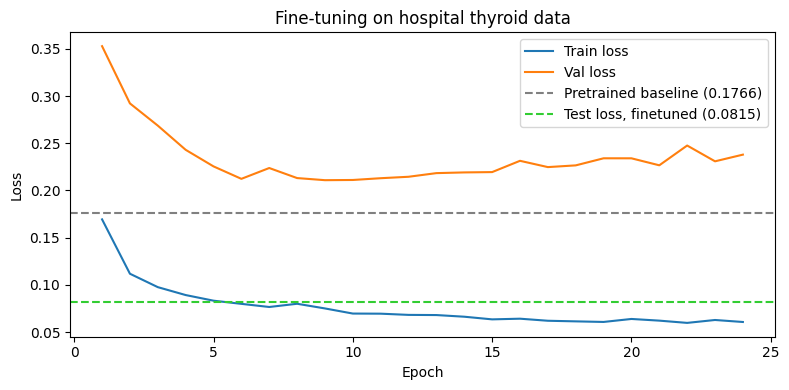

In [ ]:
epochs = range(1, len(ft_history['train_loss']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, ft_history['train_loss'], label='Train loss')
plt.plot(epochs, ft_history['val_loss'],   label='Val loss')
plt.axhline(y=baseline_loss, color='gray', linestyle='--', label=f'Pretrained baseline ({baseline_loss:.4f})')
plt.axhline(y=finetuned_loss, color='limegreen', linestyle='--', label=f'Test loss, finetuned ({finetuned_loss:.4f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-tuning on hospital thyroid data')
plt.legend()
plt.tight_layout()
plt.savefig('finetune_history.png', dpi=150)
plt.show()

In [ ]:
# running model on test set and saving as NIfTI

THRESHOLD = 0.2

finetuned_model_eval.eval()
with torch.no_grad():
    for trans, long_vid, meta in test_loader:
        trans    = trans.to(DEVICE)
        long_vid = long_vid.to(DEVICE)
        pred_logits = finetuned_model_eval(trans, long_vid)
        pred_vol = (torch.sigmoid(pred_logits) > THRESHOLD).float()

        for b in range(pred_vol.shape[0]):
            vol_numpy = pred_vol[b, 0].cpu().numpy()
            sitk_image = sitk.GetImageFromArray(vol_numpy.astype(np.float32))
            sitk_image.SetSpacing((1.0, 1.0, 1.0))
            filename = f'hospital_recon_{meta[b]}.nii.gz'
            sitk.WriteImage(sitk_image, filename)
            print(f'Saved: {filename}')

Saved: hospital_recon_ULT432_nod1_p1.nii.gz


In [43]:
# # for checks

# for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
#     pred_vol = (torch.sigmoid(pred_logits) > threshold).float()
#     vol_numpy = pred_vol[0, 0].cpu().numpy()
#     sitk_image = sitk.GetImageFromArray(vol_numpy.astype(np.float32))
#     sitk_image.SetSpacing((1.0, 1.0, 1.0))
#     sitk.WriteImage(sitk_image, f'hospital_recon_thresh{threshold}.nii.gz')
#     print(f'threshold {threshold}: {int(vol_numpy.sum())} active voxels')

threshold 0.5: 1726 active voxels
threshold 0.3: 10517 active voxels
threshold 0.2: 24807 active voxels
threshold 0.1: 65749 active voxels
threshold 0.05: 136369 active voxels
